# 01 — UN Comtrade: Data Cleaning & Transformation
**MSBA 305 | Maritime Shipping Intelligence Pipeline**

**Source:** UN Comtrade Database (comtradeplus.un.org)
**Input:** `data/raw/TradeData_*.csv` (your downloaded file)
**Output:** `data/clean/un_comtrade_clean.csv` + quality report

---
### Pipeline position
```
[UN Comtrade CSV] → [THIS NOTEBOOK] → [data/clean/] → [04_combine_EDA] → [BigQuery]
```
---
### Data Source Appraisal (Section 4.1.1 of rubric)
| Dimension | Detail |
|-----------|--------|
| **Origin** | UN Statistics Division — global trade reporters |
| **Format** | CSV, rigid schema, 46 columns |
| **Volume** | ~50K rows per download, updated annually |
| **Quality issues** | Missing weight data, null transport mode, ISO code inconsistencies |
| **Bias** | Under-reports informal trade; some countries report with 12-month lag |
| **Access** | Free download, max 500 rows per query without subscription |

## 0. Setup — Mount Drive & Navigate

In [1]:
import os, sys, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Environment detection: works in Colab and local/GitHub clone ──────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/repo'
    print('Running in Google Colab')
except ImportError:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f'Running locally — BASE: {BASE}')

RAW_DIR    = os.path.join(BASE, 'data', 'raw')
CLEAN_DIR  = os.path.join(BASE, 'data', 'clean')
CLEAN_PATH = os.path.join(CLEAN_DIR, 'un_comtrade_clean.csv')
os.makedirs(CLEAN_DIR, exist_ok=True)

print('Libraries loaded successfully')


Mounted at /content/drive
/content/drive/MyDrive/repo/notebooks
Libraries loaded successfully


## 1. Load Raw Data
Auto-detects your TradeData file by name pattern.

In [2]:
# Auto-detect Comtrade file (handles any date-stamped filename)
candidates = (
    glob.glob(f'{RAW_DIR}/TradeData*.csv') +
    glob.glob(f'{RAW_DIR}/un_comtrade*.csv') +
    glob.glob(f'{RAW_DIR}/comtrade*.csv')
)

if not candidates:
    raise FileNotFoundError(
        f'No Comtrade CSV found in {RAW_DIR}. '
        'Upload your TradeData file there first.'
    )

# use most recent if multiple
RAW_PATH = sorted(candidates)[-1]
print(f'Using file: {os.path.basename(RAW_PATH)}')
print(f'File size:  {os.path.getsize(RAW_PATH)/1e6:.1f} MB')

df = pd.read_csv(RAW_PATH, encoding='latin1', low_memory=False, index_col=False)

before_rows  = len(df)
before_nulls = df.isnull().sum().sum()

print(f'Rows:    {before_rows:,}')
print(f'Columns: {df.shape[1]}')
print(f'Nulls:   {before_nulls:,}')
df.head(3)

Using file: TradeData_4_4_2026_18_51_44.csv
File size:  5.6 MB
Rows:    16,444
Columns: 47
Nulls:   57,351


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20150101,2015,52,2015,4,AFG,Afghanistan,M,...,NaN,False,NaN,False,58451404.0,NaN,58451404.0,0,True,False
1,C,A,20150101,2015,52,2015,4,AFG,Afghanistan,X,...,NaN,False,NaN,False,NaN,45161.0,45161.0,0,True,False
2,C,A,20150101,2015,52,2015,8,ALB,Albania,M,...,NaN,False,NaN,False,95925676.0,NaN,95925676.0,0,True,False


In [3]:
# Quick null overview — paste these numbers in your quality report
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('Null % per column (only columns with >0 nulls):')
print(null_pct[null_pct > 0].to_string())

Null % per column (only columns with >0 nulls):
qtyUnitAbbr       100.000000
altQtyUnitAbbr    100.000000
cifvalue           38.956458
netWgt             35.800292
fobvalue           34.620530
grossWgt           20.730966
altQty              9.328631
qty                 9.328631


## 2. Drop Metadata Columns
**Decision (for report):** Remove 20 UN internal metadata columns that provide no analytical value. These include internal flags, rarely-populated fields, and reference codes duplicated by descriptor columns.

In [4]:
DROP_COLS = [
    'typeCode','freqCode','refPeriodId','refMonth',
    'partner2Code','partner2ISO','partner2Desc',
    'classificationCode','classificationSearchCode','isOriginalClassification',
    'customsCode','customsDesc','mosCode',
    'legacyEstimationFlag','isReported','isAggregate',
    'grossWgt',
    'altQtyUnitCode','altQtyUnitAbbr','altQty','isAltQtyEstimated',
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=DROP_COLS, inplace=True)
print(f'Dropped {len(DROP_COLS)} metadata columns')
print(f'Remaining: {df.shape[1]} columns')

Dropped 21 metadata columns
Remaining: 26 columns


## 3. Rename to snake_case (BigQuery compatible)

In [5]:
RENAME = {
    'reporterISO':'reporter_iso','reporterDesc':'reporter_country',
    'reporterCode':'reporter_code','flowCode':'flow_code',
    'flowDesc':'flow_direction','partnerCode':'partner_code',
    'partnerISO':'partner_iso','partnerDesc':'partner_country',
    'cmdCode':'hs_code','cmdDesc':'commodity',
    'aggrLevel':'aggregation_level','isLeaf':'is_leaf',
    'motCode':'transport_mode_code','motDesc':'transport_mode',
    'qtyUnitCode':'qty_unit_code','qtyUnitAbbr':'qty_unit',
    'qty':'quantity','isQtyEstimated':'qty_estimated',
    'netWgt':'net_weight_kg','isNetWgtEstimated':'weight_estimated',
    'cifvalue':'cif_value_usd','fobvalue':'fob_value_usd',
    'primaryValue':'trade_value_usd','refYear':'year','period':'period',
}
RENAME = {k:v for k,v in RENAME.items() if k in df.columns}
df.rename(columns=RENAME, inplace=True)
print('Renamed to snake_case')
print(df.columns.tolist())

Renamed to snake_case
['year', 'period', 'reporter_code', 'reporter_iso', 'reporter_country', 'flow_code', 'flow_direction', 'partner_code', 'partner_iso', 'partner_country', 'hs_code', 'commodity', 'aggregation_level', 'is_leaf', 'transport_mode_code', 'transport_mode', 'qty_unit_code', 'qty_unit', 'quantity', 'qty_estimated', 'net_weight_kg', 'weight_estimated', 'isGrossWgtEstimated', 'cif_value_usd', 'fob_value_usd', 'trade_value_usd']


## 4. Filter — Keep Shipping-Relevant HS Codes Only
**Decision (for report):** Keep 5 HS codes directly relevant to maritime shipping. Rejected alternative: keep all HS codes — this would include electronics, software, services that are irrelevant to our domain and inflate dataset without analytical value.

In [6]:
# SHIPPING_HS = {
#     '89': 'Ships & floating structures',
#     '27': 'Mineral fuels & crude oil',
#     '72': 'Iron & steel (bulk cargo)',
#     '10': 'Cereals (grain shipping)',
#     '26': 'Ores & slag (dry bulk)',
#     'TOTAL': 'All commodities aggregate'
# }

# if 'hs_code' in df.columns:
#     df['hs_code'] = df['hs_code'].astype(str).str.strip()
#     before = len(df)
#     df = df[df['hs_code'].isin(SHIPPING_HS.keys())]
#     print(f'Rows before HS filter: {before:,}')
#     print(f'Rows after HS filter:  {len(df):,}')
#     print('\nHS code distribution:')
#     vc = df['hs_code'].value_counts()
#     for code, count in vc.items():
#         print(f'  HS {code} ({SHIPPING_HS.get(code,"")}): {count:,} rows')
# else:
#     print('WARNING: hs_code column not found — check column names above')

## 5. Handle Missing Values
**Rubric requirement (Section 4.3):** Document each decision — deletion, imputation, or flagging.

In [7]:
print('=== BEFORE HANDLING ===')
print(df.isnull().sum()[df.isnull().sum()>0].to_string())
print()

=== BEFORE HANDLING ===
qty_unit         16444
quantity          1534
net_weight_kg     5887
cif_value_usd     6406
fob_value_usd     5693



In [8]:
# trade_value_usd → DROP rows (critical column, no value = row unusable)
n = df['trade_value_usd'].isnull().sum()
df = df[df['trade_value_usd'].notna()]
print(f'trade_value_usd: dropped {n} null rows — decision: deletion (critical column)')

# net_weight_kg → FILL with 0, flag estimated
# Decision: not all reporters submit weight; 0 preserves the row for trade value analysis
if 'net_weight_kg' in df.columns:
    n = df['net_weight_kg'].isnull().sum()
    df['net_weight_kg'] = df['net_weight_kg'].fillna(0)
    if 'weight_estimated' in df.columns:
        df['weight_estimated'] = df['weight_estimated'].fillna(True)
    print(f'net_weight_kg:   filled {n} nulls with 0 — decision: imputation (optional field)')

# transport_mode → FILL with 'Not specified'
# Decision: mode is optional in UN submissions; null ≠ error
if 'transport_mode' in df.columns:
    n = df['transport_mode'].isnull().sum()
    df['transport_mode'] = df['transport_mode'].fillna('Not specified')
    print(f'transport_mode:  filled {n} nulls — decision: flagging as Not specified')

# quantity → FILL with 0
if 'quantity' in df.columns:
    n = df['quantity'].isnull().sum()
    df['quantity'] = df['quantity'].fillna(0)
    print(f'quantity:        filled {n} nulls with 0 — decision: imputation')

print(f'\nRows remaining: {len(df):,}')

trade_value_usd: dropped 0 null rows — decision: deletion (critical column)
net_weight_kg:   filled 5887 nulls with 0 — decision: imputation (optional field)
transport_mode:  filled 0 nulls — decision: flagging as Not specified
quantity:        filled 1534 nulls with 0 — decision: imputation

Rows remaining: 16,444


## 6. Remove Duplicates

In [9]:
pk = [c for c in ['reporter_iso','partner_iso','hs_code','flow_direction','year'] if c in df.columns]
before = len(df)
df.drop_duplicates(subset=pk, keep='first', inplace=True)
print(f'Duplicates removed: {before - len(df)}')
print(f'Primary key used: {pk}')

Duplicates removed: 0
Primary key used: ['reporter_iso', 'partner_iso', 'hs_code', 'flow_direction', 'year']


## 7. Standardize Formats

In [10]:
if not df.empty:
    if 'year' in df.columns:
        df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    if 'trade_value_usd' in df.columns:
        df['trade_value_usd'] = pd.to_numeric(df['trade_value_usd'], errors='coerce').round(2)
    if 'flow_direction' in df.columns:
        df['flow_direction'] = df['flow_direction'].astype(str).str.strip().str.title()
    for col in ['reporter_iso','partner_iso']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.upper()
    for col in ['reporter_country','partner_country','commodity']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    print('Formats standardized — dates, casing, numeric types')
else:
    print('DataFrame is empty, skipping format standardization.')

Formats standardized — dates, casing, numeric types


## 8. Flag Outliers (do NOT delete)
**Decision (for report):** Flag with `is_outlier=True` rather than delete. Large trade values (China→World) are legitimate — deletion would introduce bias.

In [11]:
df['is_outlier'] = False
if 'hs_code' in df.columns:
    for code, grp in df.groupby('hs_code'):
        mean = grp['trade_value_usd'].mean()
        std  = grp['trade_value_usd'].std()
        mask = df['hs_code'] == code
        df.loc[mask,'is_outlier'] = ((df.loc[mask,'trade_value_usd'] - mean).abs() > 3 * std)
print(f'Outliers flagged: {df["is_outlier"].sum()} rows (>3σ per HS code)')
print('Strategy: flagged only — NOT deleted')
df[df['is_outlier']][['reporter_country','hs_code','year','trade_value_usd']].head(5)

Outliers flagged: 301 rows (>3σ per HS code)
Strategy: flagged only — NOT deleted


,reporter_country,hs_code,year,trade_value_usd
73,Australia,26,2015,4.784254e+10
288,Canada,10,2015,7.335450e+09
297,China,10,2015,9.347989e+09
326,China,26,2015,9.372007e+10
357,China,27,2015,1.986007e+11


## 9. Add Derived Columns

In [12]:
# trade_balance = exports - imports
if 'flow_direction' in df.columns:
    pivot = df.pivot_table(
        index=['reporter_iso','partner_iso','hs_code','year'],
        columns='flow_direction', values='trade_value_usd', aggfunc='sum'
    ).reset_index()
    pivot.columns.name = None
    if 'Export' in pivot.columns and 'Import' in pivot.columns:
        pivot['trade_balance_usd'] = pivot['Export'].fillna(0) - pivot['Import'].fillna(0)
        df = df.merge(
            pivot[['reporter_iso','partner_iso','hs_code','year','trade_balance_usd']],
            on=['reporter_iso','partner_iso','hs_code','year'], how='left'
        )
        print('Added: trade_balance_usd')

# value_per_kg
if 'net_weight_kg' in df.columns:
    df['value_per_kg'] = np.where(
        df['net_weight_kg'] > 0,
        (df['trade_value_usd'] / df['net_weight_kg']).round(4), np.nan
    )
    print('Added: value_per_kg')

# decade bucket
if 'year' in df.columns:
    df['decade'] = (df['year'] // 10 * 10).astype('Int64')
    print('Added: decade')

# source tag — essential for combine_sources step
df['source']      = 'un_comtrade'
df['data_type']   = 'trade_flow'
df['granularity'] = 'annual'
print('Added: source, data_type, granularity tags')

Added: trade_balance_usd
Added: value_per_kg
Added: decade
Added: source, data_type, granularity tags


## 10. Data Validation (Pydantic-style checks)

In [13]:
errors = []
if df['trade_value_usd'].isnull().sum() > 0:
    errors.append('FAIL: nulls remain in trade_value_usd')
if df['reporter_iso'].isnull().sum() > 0:
    errors.append('FAIL: nulls remain in reporter_iso')
if (df['trade_value_usd'] < 0).sum() > 0:
    errors.append('FAIL: negative trade values found')
if df.duplicated(subset=['reporter_iso','partner_iso','hs_code','flow_direction','year']).sum() > 0:
    errors.append('FAIL: duplicates remain after dedup')

if errors:
    print('VALIDATION ERRORS:')
    for e in errors: print(f'  {e}')
else:
    print('All validation checks PASSED')
    print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

All validation checks PASSED
Final shape: 16,444 rows x 33 columns


## 11. Quick EDA Plots

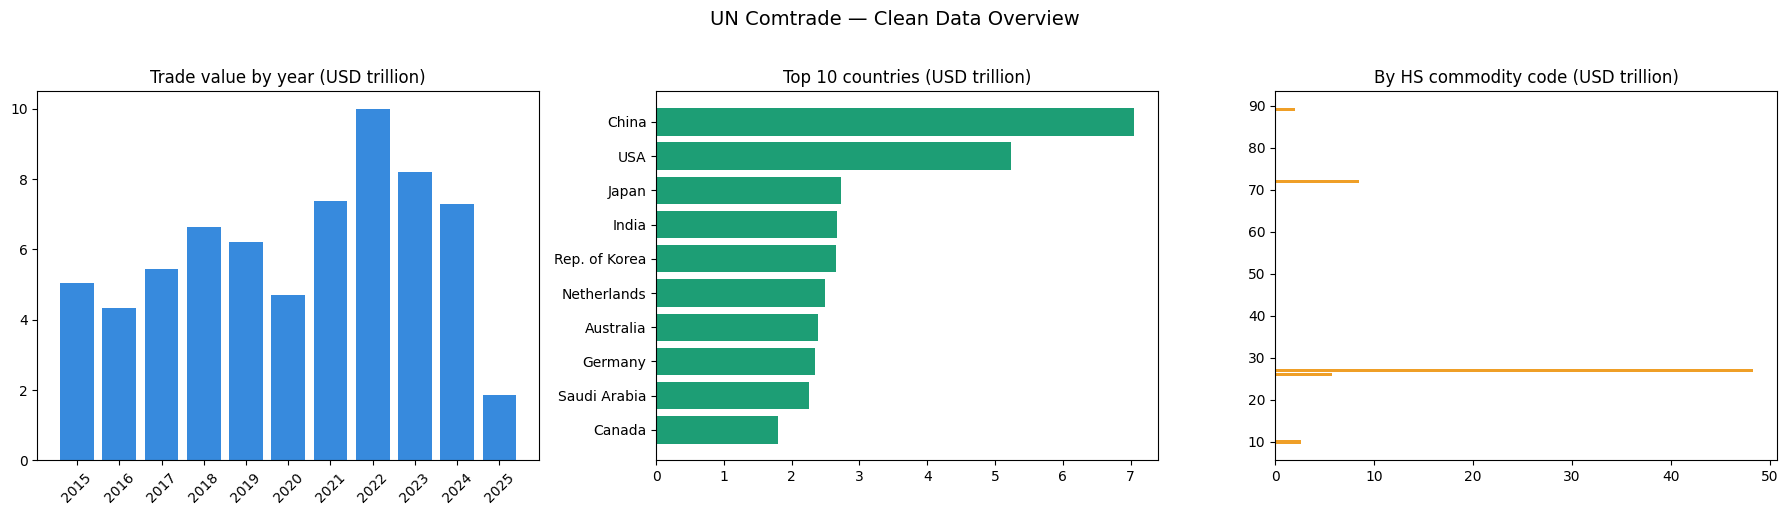

Saved → data/clean/comtrade_eda.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Trade value by year
if 'year' in df.columns:
    yearly = df.groupby('year')['trade_value_usd'].sum() / 1e12
    axes[0].bar(yearly.index.astype(str), yearly.values, color='#378ADD')
    axes[0].set_title('Trade value by year (USD trillion)')
    axes[0].tick_params(axis='x', rotation=45)

# Top 10 reporters
if 'reporter_country' in df.columns:
    top10 = df.groupby('reporter_country')['trade_value_usd'].sum().nlargest(10) / 1e12
    axes[1].barh(top10.index, top10.values, color='#1D9E75')
    axes[1].invert_yaxis()
    axes[1].set_title('Top 10 countries (USD trillion)')

# By HS code
if 'hs_code' in df.columns:
    by_hs = df.groupby('hs_code')['trade_value_usd'].sum() / 1e12
    axes[2].barh(by_hs.index, by_hs.values, color='#EF9F27')
    axes[2].set_title('By HS commodity code (USD trillion)')

plt.suptitle('UN Comtrade — Clean Data Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/comtrade_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/clean/comtrade_eda.png')

## 12. Save Clean Data + Quality Report

In [15]:
df.to_csv(CLEAN_PATH, index=False)
print(f'Clean data saved → {CLEAN_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Clean data saved → /content/drive/MyDrive/repo/data/clean/un_comtrade_clean.csv
Shape: 16,444 rows x 33 columns


,year,period,reporter_code,reporter_iso,reporter_country,flow_code,flow_direction,partner_code,partner_iso,partner_country,...,cif_value_usd,fob_value_usd,trade_value_usd,is_outlier,trade_balance_usd,value_per_kg,decade,source,data_type,granularity
0,2015,2015,4,AFG,Afghanistan,M,Import,0,W00,World,...,58451404.0,NaN,58451404.0,False,-58406243.0,NaN,2010,un_comtrade,trade_flow,annual
1,2015,2015,4,AFG,Afghanistan,X,Export,0,W00,World,...,NaN,45161.0,45161.0,False,-58406243.0,NaN,2010,un_comtrade,trade_flow,annual
2,2015,2015,8,ALB,Albania,M,Import,0,W00,World,...,95925676.0,NaN,95925676.0,False,-95867992.0,NaN,2010,un_comtrade,trade_flow,annual


In [16]:
after_rows  = len(df)
after_nulls = df.isnull().sum().sum()
report = f"""UN COMTRADE — DATA QUALITY REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Source file: {os.path.basename(RAW_PATH)}
{'='*55}

BEFORE CLEANING
  Rows:          {before_rows:,}
  Total nulls:   {before_nulls:,}
  Columns:       {df.shape[1]}

AFTER CLEANING
  Rows:          {after_rows:,}  (removed {before_rows - after_rows:,})
  Total nulls:   {after_nulls:,}

MISSING VALUE DECISIONS
  trade_value_usd → DELETED (critical column, no value = unusable row)
  net_weight_kg   → IMPUTED with 0 (optional field, weight_estimated=True)
  transport_mode  → FLAGGED as 'Not specified' (optional UN field)
  quantity        → IMPUTED with 0 (not all reporters submit quantity)

OUTLIERS
  Flagged: {df['is_outlier'].sum()} rows (>3 std dev per HS code)
  Strategy: is_outlier=True flag — NOT deleted (large values are legitimate)

COVERAGE
  Years:      {sorted(df['year'].dropna().unique().tolist()) if 'year' in df.columns else 'N/A'}
  Countries:  {df['reporter_iso'].nunique() if 'reporter_iso' in df.columns else 'N/A'} unique reporters
  HS codes:   {df['hs_code'].unique().tolist() if 'hs_code' in df.columns else 'N/A'}

TRADE VALUE (USD)
  Min:    ${df['trade_value_usd'].min():,.0f}
  Max:    ${df['trade_value_usd'].max():,.0f}
  Mean:   ${df['trade_value_usd'].mean():,.0f}
  Median: ${df['trade_value_usd'].median():,.0f}

NULL % BY COLUMN (after cleaning)
{df.isnull().mean().mul(100).round(1).to_string()}
"""

with open(f'{CLEAN_DIR}/comtrade_quality_report.txt','w') as f:
    f.write(report)
print(report[:800])
print(f'\nFull report saved → {CLEAN_DIR}/comtrade_quality_report.txt')
print('DONE — run 02_ingest_clean_bdi.ipynb next')

UN COMTRADE — DATA QUALITY REPORT
Generated: 2026-04-04 21:06
Source file: TradeData_4_4_2026_18_51_44.csv

BEFORE CLEANING
  Rows:          16,444
  Total nulls:   57,351
  Columns:       33

AFTER CLEANING
  Rows:          16,444  (removed 0)
  Total nulls:   44,987

MISSING VALUE DECISIONS
  trade_value_usd → DELETED (critical column, no value = unusable row)
  net_weight_kg   → IMPUTED with 0 (optional field, weight_estimated=True)
  transport_mode  → FLAGGED as 'Not specified' (optional UN field)
  quantity        → IMPUTED with 0 (not all reporters submit quantity)

OUTLIERS
  Flagged: 301 rows (>3 std dev per HS code)
  Strategy: is_outlier=True flag — NOT deleted (large values are legitimate)

COVERAGE
  Years:      [2015, 201

Full report saved → /content/drive/MyDrive/repo/data/clean/comtrade_quality_report.txt
DONE — run 02_ingest_clean_bdi.ipynb next


## 13. Drop Null Columns & Add Derived Columns

In [17]:
# Drop columns that are 100% null — they add no value and inflate the schema
# qty_unit       → 100% null: no quantity unit for HS-specific codes when partner=World
# value_per_kg   → 100% null: weight not reported at this aggregation level
# isGrossWgtEstimated → leftover raw column that should have been in DROP_COLS
NULL_DROP = [c for c in ['qty_unit', 'value_per_kg', 'isGrossWgtEstimated'] if c in df.columns]
if NULL_DROP:
    df.drop(columns=NULL_DROP, inplace=True)
    print(f'Dropped null columns: {NULL_DROP}')
else:
    print('Null columns already absent — nothing to drop')

# Add trade_value_trillion — cleaner label for charts
df['trade_value_trillion'] = (df['trade_value_usd'] / 1e12).round(4)

# Add yoy_growth_pct — year-over-year export/import growth per country
df_sorted = df.sort_values(['reporter_iso', 'flow_direction', 'year'])
df['yoy_growth_pct'] = (
    df_sorted
    .groupby(['reporter_iso', 'flow_direction'])['trade_value_usd']
    .pct_change()
    .mul(100)
    .round(2)
)

print(f'Added: trade_value_trillion, yoy_growth_pct')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Remaining null columns: {[c for c in df.columns if df[c].isnull().all()]}')

# Re-save with the clean, final version
df.to_csv(CLEAN_PATH, index=False)
print(f'Re-saved → {CLEAN_PATH}')

Dropped null columns: ['qty_unit', 'value_per_kg', 'isGrossWgtEstimated']
Added: trade_value_trillion, yoy_growth_pct
Final shape: 16,444 rows x 32 columns
Remaining null columns: []
Re-saved → /content/drive/MyDrive/repo/data/clean/un_comtrade_clean.csv


## 14. Final Column Overview

In [18]:
print('Final columns and null rates:')
for col in df.columns:
    null_pct = df[col].isnull().mean() * 100
    flag = ' ← documented (reporters submit FOB or CIF, not both)' if col in ['cif_value_usd','fob_value_usd'] else ''
    flag = ' ← first year per group always null (no prior year)' if col == 'yoy_growth_pct' else flag
    if null_pct > 0:
        print(f'  {col:<30} {null_pct:5.1f}% null{flag}')
    else:
        print(f'  {col:<30} complete')
print()
print('Top 5 exporters (USD trillion, 2015-2025):')
top5 = df[df['flow_direction']=='Export'].groupby('reporter_country')['trade_value_usd'].sum().nlargest(5)/1e12
print(top5.round(2).to_string())
print()
print('DONE — run 05_combine_EDA_fixed.ipynb next')

Final columns and null rates:
  year                           complete
  period                         complete
  reporter_code                  complete
  reporter_iso                   complete
  reporter_country               complete
  flow_code                      complete
  flow_direction                 complete
  partner_code                   complete
  partner_iso                    complete
  partner_country                complete
  hs_code                        complete
  commodity                      complete
  aggregation_level              complete
  is_leaf                        complete
  transport_mode_code            complete
  transport_mode                 complete
  qty_unit_code                  complete
  quantity                       complete
  qty_estimated                  complete
  net_weight_kg                  complete
  weight_estimated               complete
  cif_value_usd                   39.0% null ← documented (reporters submit FOB or CIF, 